# Thai Vowel Classification — LSTM + Mel Spectrogram




## Section 1 — Setup

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.font_manager as fm
import urllib.request
from pydub import AudioSegment
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Mounted at /content/drive


In [ ]:
# ── Constants ───────────────────────────────────────────────
SR          = 16000
HOP_LENGTH  = 512
N_FFT       = 2048
N_CLASSES   = 18
EPOCHS      = 100
BATCH_SIZE  = 32
RANDOM_SEED = 42
N_FOLDS     = 5

VOWEL_LABELS = [
    'อา','อี','อือ','อู','เอ','แอ','โอ','ออ','เออ',
    'อะ','อิ','อึ','อุ','เอะ','แอะ','โอะ','เอาะ','เออะ'
]

# ── Fix Random Seed ─────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'Random seed fixed: {RANDOM_SEED}')

Random seed fixed: 42


## Section 2 — Load Dataset

In [ ]:
base_path = r'/content/drive/My Drive/dataset'

data = []
for label in os.listdir(base_path):
    folder = os.path.join(base_path, label)
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith('.wav'):
                data.append([os.path.join(folder, file), label])

df = pd.DataFrame(data, columns=['file_path', 'label'])
print(f'Total samples : {len(df)}')
print(df['label'].value_counts())

Total samples : 1800
label
s4    100
s7    100
s8    100
s9    100
s2    100
s6    100
s5    100
s3    100
s1    100
09    100
08    100
06    100
07    100
03    100
05    100
04    100
02    100
01    100
Name: count, dtype: int64


## Section 3 — Preprocessing Functions

In [ ]:
def detect_leading_silence(sound, silence_threshold=-30.0, chunk_size=10):

    trim_ms = 0
    while trim_ms < len(sound) and sound[trim_ms:trim_ms+chunk_size].dBFS < silence_threshold:
        trim_ms += chunk_size
    return trim_ms


def smart_crop(file_path, output_dir, window_ms=500, silence_threshold=-30.0):

    os.makedirs(output_dir, exist_ok=True)
    sound = AudioSegment.from_file(file_path)

    start = detect_leading_silence(sound, silence_threshold)
    end   = detect_leading_silence(sound.reverse(), silence_threshold)
    trimmed = sound[start : len(sound) - end]

    if len(trimmed) == 0:
        trimmed = sound

    chunk_ms  = 10
    energies  = [trimmed[i:i+chunk_ms].rms for i in range(0, len(trimmed), chunk_ms)]
    peak_idx  = int(np.argmax(energies))
    peak_ms   = peak_idx * chunk_ms

    half       = window_ms // 2
    crop_start = max(0, peak_ms - half)
    crop_end   = min(len(trimmed), crop_start + window_ms)
    final      = trimmed[crop_start:crop_end]

    out_path = os.path.join(output_dir, f'sc_{os.path.basename(file_path)}')
    final.export(out_path, format='wav')
    return out_path

## Section 4 — Feature Extraction (Log-Mel Spectrogram)

In [ ]:
def extract_mel_sequence(file_path, max_len=18):

    wave, _ = librosa.load(file_path, mono=True, sr=SR)

    mel    = librosa.feature.melspectrogram(y=wave, sr=SR,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    return mel_db.T  # (max_len, n_mels) time-first

## Section 5 — Dataset Analysis (duration percentiles)

Run once to justify MAX_LEN choice.

In [ ]:
durations = []
for fp in tqdm(df['file_path'], desc='Measuring durations'):
    y, _ = librosa.load(fp, sr=SR)
    durations.append(len(y) / SR)

durations = np.array(durations)
print('Duration stats (seconds):')
for p in [25, 50, 75, 90, 95]:
    frames = int(np.percentile(durations, p) * SR / HOP_LENGTH)
    print(f'  p{p}: {np.percentile(durations, p):.3f}s → {frames} frames')

Measuring durations: 100%|██████████| 1800/1800 [09:41<00:00,  3.09it/s]

Duration stats (seconds):
  p25: 0.123s → 3 frames
  p50: 0.226s → 7 frames
  p75: 0.375s → 11 frames
  p90: 0.491s → 15 frames
  p95: 0.576s → 18 frames


## Section 6 — Build Full Dataset

In [ ]:
PROC_DIR = '/content/proc_smartcrop'

MAX_LEN  = 18

processed_paths = [
    smart_crop(fp, PROC_DIR)
    for fp in tqdm(df['file_path'], desc='smart_crop')
]

X = np.array([
    extract_mel_sequence(p,  max_len=MAX_LEN)
    for p in tqdm(processed_paths, desc='Mel extraction')
])  # (N, MAX_LEN, N_MELS)

le    = LabelEncoder()
y_int = le.fit_transform(df['label'])

print(f'X shape : {X.shape}  (samples, timesteps, mel_bins)')
print(f'Classes : {le.classes_}')

Mel extraction:   0%|          | 0/1800 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1952
  warnings.warn(
Mel extraction:   0%|          | 1/1800 [00:01<31:04,  1.04s/it]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1776
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1440
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1808
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1472
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too

X shape : (1800, 18, 128)  (samples, timesteps, mel_bins)
Classes : ['01' '02' '03' '04' '05' '06' '07' '08' '09' 's1' 's2' 's3' 's4' 's5'
 's6' 's7' 's8' 's9']


## Section 7 — Hold-Out Test Split (10%)

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_int,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_int
)

print(f'Train+Val : {X_trainval.shape[0]} samples')
print(f'Test      : {X_test.shape[0]} samples  ')

Train+Val : 1620 samples
Test      : 180 samples  


## Section 8 — Model Architecture (LSTM)

In [ ]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dropout(0.35),
        layers.LSTM(
            512,
            activation='tanh',
            dropout=0.35,
            return_sequences=True
        ),
        layers.LSTM(
            512,
            activation='tanh',
            dropout=0.35
        ),

        layers.Dense(
            N_CLASSES,
            activation='softmax'
        )
    ])


    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

dummy = build_model((X_trainval.shape[1], X_trainval.shape[2]))
dummy.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 18, 512)        │     1,312,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 512)            │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 18)             │         9,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,421,202 (13.05 MB)

 Trainable params: 3,421,202 (13.05 MB)

 Non-trainable params: 0 (0.00 B)

## Section 9 — Stratified 5-Fold Cross-Validation

In [ ]:
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_results = []

X_tv = X_trainval  # no channel dim for LSTM

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f'\n── Fold {fold}/{N_FOLDS} ──')

    random.seed(RANDOM_SEED * fold)
    np.random.seed(RANDOM_SEED * fold)
    tf.random.set_seed(RANDOM_SEED * fold)

    X_tr,  X_val  = X_tv[tr_idx],      X_tv[val_idx]
    y_tr,  y_val  = y_trainval[tr_idx], y_trainval[val_idx]

    y_tr_cat  = to_categorical(y_tr,  N_CLASSES)
    y_val_cat = to_categorical(y_val, N_CLASSES)

    model = build_model(X_tr.shape[1:])
    es    = EarlyStopping(monitor='val_loss', patience=15,
                          restore_best_weights=True, verbose=0)

    model.fit(
        X_tr, y_tr_cat,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val_cat),
        callbacks=[es], verbose=0
    )

    # ── ดึง loss/accuracy หลัง restore best weights ──
    val_loss, val_acc_eval = model.evaluate(X_val, y_val_cat, verbose=0)
    train_loss, train_acc_eval = model.evaluate(X_tr, y_tr_cat, verbose=0)

    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    f1     = f1_score(y_val, y_pred, average='macro')
    acc    = np.mean(y_pred == y_val)

    fold_results.append({
        'fold': fold,
        'val_acc': acc,
        'val_f1_macro': f1,
        'val_loss': val_loss,
        'train_loss': train_loss,
    })
    print(f'  Val Acc: {acc*100:.2f}%   Macro F1: {f1:.4f}   Val Loss: {val_loss:.4f}   Train Loss: {train_loss:.4f}')

df_folds = pd.DataFrame(fold_results)
print('\n' + '='*55)
print('  CV Summary')
print('='*55)
print(f"  Val Acc    : {df_folds['val_acc'].mean()*100:.2f}% ± {df_folds['val_acc'].std()*100:.2f}%")
print(f"  Macro F1   : {df_folds['val_f1_macro'].mean():.4f} ± {df_folds['val_f1_macro'].std():.4f}")
print(f"  Val Loss   : {df_folds['val_loss'].mean():.4f} ± {df_folds['val_loss'].std():.4f}")
print(f"  Train Loss : {df_folds['train_loss'].mean():.4f} ± {df_folds['train_loss'].std():.4f}")
print('='*55)


── Fold 1/5 ──
  Val Acc: 87.96%   Macro F1: 0.8803   Val Loss: 0.3796   Train Loss: 0.2172

── Fold 2/5 ──
  Val Acc: 88.89%   Macro F1: 0.8892   Val Loss: 0.3544   Train Loss: 0.2394

── Fold 3/5 ──
  Val Acc: 87.96%   Macro F1: 0.8802   Val Loss: 0.3885   Train Loss: 0.1749

── Fold 4/5 ──
  Val Acc: 92.90%   Macro F1: 0.9285   Val Loss: 0.2829   Train Loss: 0.2329

── Fold 5/5 ──
  Val Acc: 86.73%   Macro F1: 0.8673   Val Loss: 0.4209   Train Loss: 0.2212

  CV Summary
  Val Acc    : 88.89% ± 2.37%
  Macro F1   : 0.8891 ± 0.0234
  Val Loss   : 0.3652 ± 0.0518
  Train Loss : 0.2171 ± 0.0252


## Section 10 — Train Final Model

In [ ]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

X_tv_final = X_trainval
y_tv_cat   = to_categorical(y_trainval, N_CLASSES)

X_tf, X_vf, y_tf, y_vf = train_test_split(
    X_tv_final, y_tv_cat, test_size=0.1,
    random_state=RANDOM_SEED, stratify=y_trainval
)

final_model = build_model(X_tf.shape[1:])
es_final    = EarlyStopping(monitor='val_loss', patience=15,
                             restore_best_weights=True, verbose=1)

history = final_model.fit(
    X_tf, y_tf,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_vf, y_vf),
    callbacks=[es_final], verbose=1
)
print('Final model trained.')

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3052 - loss: 1.9741 - val_accuracy: 0.5802 - val_loss: 1.2261
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4979 - loss: 1.4097 - val_accuracy: 0.7901 - val_loss: 0.7573
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5898 - loss: 1.2026 - val_accuracy: 0.7901 - val_loss: 0.7243
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6324 - loss: 1.0449 - val_accuracy: 0.7593 - val_loss: 0.6900
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6276 - loss: 1.0500 - val_accuracy: 0.7840 - val_loss: 0.6868
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6619 - loss: 0.9688 - val_accuracy: 0.8210 - val_loss: 0.6030
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7010 - loss: 0.9195 - val_accuracy: 0.7901 - val_loss: 0.6353
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7133 - loss: 0.8737 - val_accuracy: 0.

## Section 11 — Evaluate on Held-Out Test Set

In [ ]:
X_te        = X_test
y_pred_test = np.argmax(final_model.predict(X_te, verbose=0), axis=1)

test_acc = np.mean(y_pred_test == y_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print('='*45)
print('  FINAL TEST RESULTS (LSTM + Mel Spectrogram)')
print('='*45)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Macro F1      : {test_f1:.4f}')
print('='*45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_test, target_names=VOWEL_LABELS))

  FINAL TEST RESULTS (LSTM + Mel Spectrogram)
  Test Accuracy : 88.89%
  Macro F1      : 0.8888

Classification Report:
              precision    recall  f1-score   support

          อา       1.00      1.00      1.00        10
          อี       1.00      0.70      0.82        10
         อือ       0.73      0.80      0.76        10
          อู       0.71      1.00      0.83        10
          เอ       0.89      0.80      0.84        10
          แอ       1.00      1.00      1.00        10
          โอ       1.00      0.70      0.82        10
          ออ       1.00      1.00      1.00        10
         เออ       0.77      1.00      0.87        10
          อะ       1.00      0.80      0.89        10
          อิ       0.73      0.80      0.76        10
          อึ       0.89      0.80      0.84        10
          อุ       0.90      0.90      0.90        10
         เอะ       0.89      0.80      0.84        10
         แอะ       1.00      1.00      1.00        10
         โอะ   

## Section 12 — Confusion Matrix

In [ ]:
# ── Thai font setup ─────────────────────────────────────────
urllib.request.urlretrieve(
    'https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf',
    '/content/Sarabun-Regular.ttf'
)
fm.fontManager.addfont('/content/Sarabun-Regular.ttf')
plt.rcParams['font.family'] = 'Sarabun'
print('Thai font loaded.')

Thai font loaded.


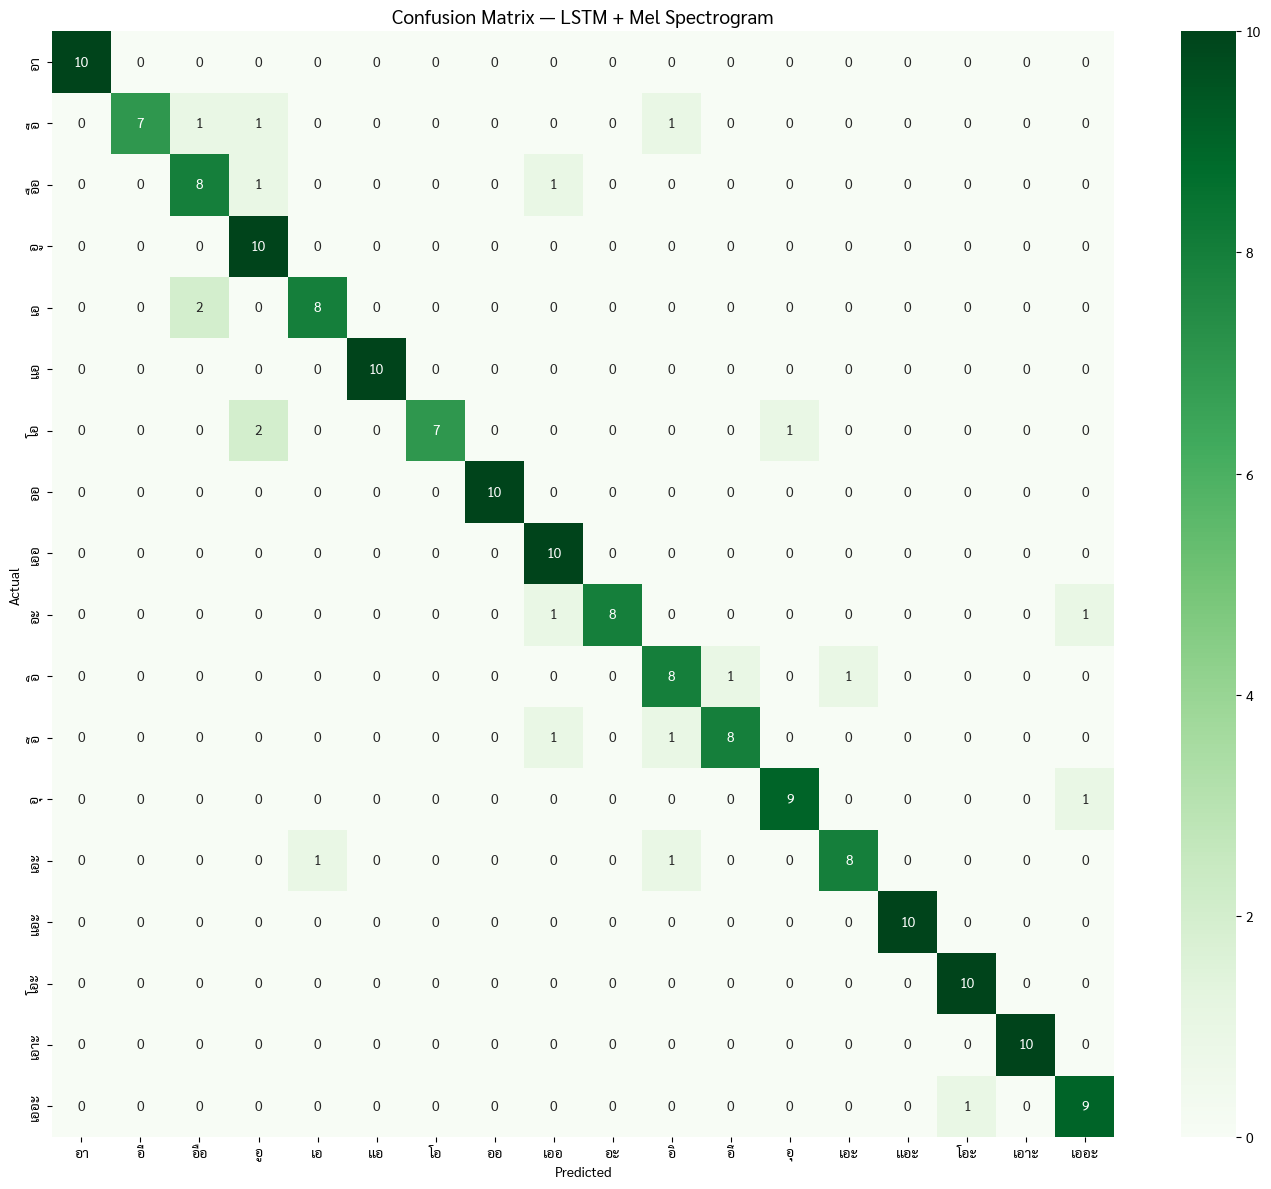

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=VOWEL_LABELS, yticklabels=VOWEL_LABELS)
plt.title('Confusion Matrix — LSTM + Mel Spectrogram', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/exp_lstm_mel_cm.png', dpi=150)
plt.show()

## Section 13 — Training Curve

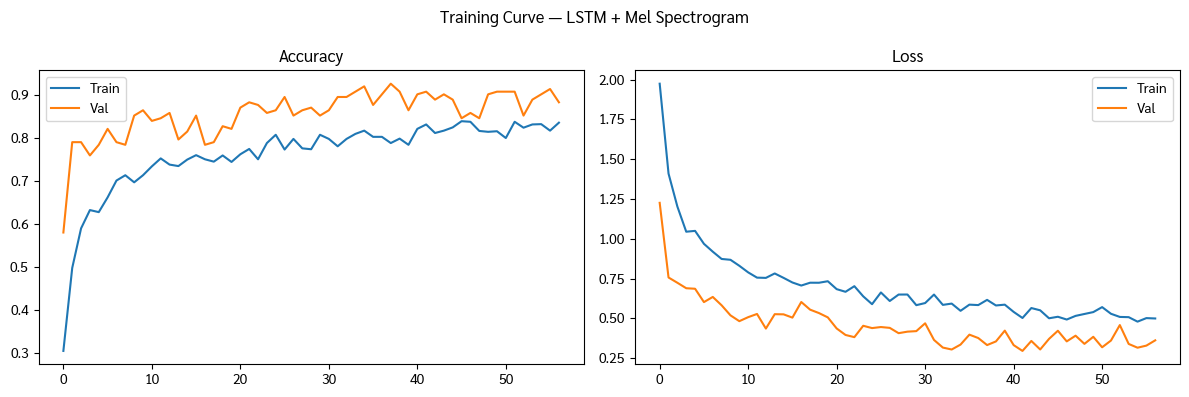

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.suptitle('Training Curve — LSTM + Mel Spectrogram')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/exp_lstm_mel_curve.png', dpi=150)
plt.show()

## Section 14 — Save Model & Results

In [ ]:


print('\n── For comparison table ──')
print(f"LSTM + Mel Spectrogram | CV F1: {df_folds['val_f1_macro'].mean():.4f}±{df_folds['val_f1_macro'].std():.4f} | Test F1: {test_f1:.4f} | Test Acc: {test_acc*100:.2f}%")


── For comparison table ──
LSTM + Mel Spectrogram | CV F1: 0.8891±0.0234 | Test F1: 0.8888 | Test Acc: 88.89%
